In [1]:
import os, sys, time
from scipy import stats
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import numpy as np
%matplotlib inline

from IPython.display import display, HTML

if (sys.version_info < (3, 0)):
    HTML('''<script>
    code_show=true; 
    function code_toggle() {
     if (code_show){
     $('div.input').hide();
     } else {
     $('div.input').show();
     }
     code_show = !code_show
    } 
    $( document ).ready(code_toggle);
    </script>
    <form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')


In [2]:
# Create timestamp to show when this summary was run
print('Summary run: ' + time.strftime("%a, %d %b %Y %H:%M"))

Summary run: Thu, 19 Jun 2025 12:07


In [3]:
relative_path = '../../../../outputs'
pd.options.display.float_format = '{:0,.0f}'.format
format_percent = "{:,.2%}".format
index_map = {0:'Rest', 1:'City of SeaTac', 'All':'All', 'TOTAL':'TOTAL'}

# Traffic Counts
----
### Daily | By Facility Type

In [4]:
df = pd.read_csv(os.path.join(relative_path,'validation','daily_volume.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')

In [5]:
_df = df.groupby('@facilitytype').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"46,740,460","43,889,218","-2,851,242",-6.10%
Arterial,"27,436,921","25,849,480","-1,587,441",-5.79%
Collector,"2,753,947","2,394,987","-358,960",-13.03%
Ramp,"449,106","335,698","-113,408",-25.25%
Total,"77,527,807","72,657,903","-4,869,904",-6.28%


#### Daily | By Facility Type - City of SeaTac

In [6]:
df1 = df[df['subarea_flag']==1]

In [7]:
_df = df1.groupby('@facilitytype').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df = _df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total']).fillna(0)
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/np.maximum(_df['observed'],1)
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"2,792,827","2,596,031","-196,796",-7.05%
Arterial,"1,878,403","1,731,848","-146,555",-7.80%
Collector,"315,623","199,448","-116,175",-36.81%
Ramp,"102,262","64,701","-37,561",-36.73%
Total,"5,130,398","4,668,136","-462,262",-9.01%


#### Daily | By Facility Type - Other Counties

In [8]:
df2 = df[df['subarea_flag'] != 1]

In [9]:
_df = df2.groupby('@facilitytype').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"43,947,633","41,293,187","-2,654,446",-6.04%
Arterial,"25,558,518","24,117,632","-1,440,886",-5.64%
Collector,"2,438,324","2,195,539","-242,785",-9.96%
Ramp,"346,844","270,997","-75,847",-21.87%
Total,"72,397,409","67,989,767","-4,407,642",-6.09%


----
### Daily | By County

In [10]:
df = pd.read_csv(os.path.join(relative_path,'validation','daily_volume_county_facility.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')

_df = df.groupby('county').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

,observed,modeled,diff,percent_diff
county,,,,
King,"43,483,299","41,991,886","-1,491,413",-3.43%
Kitsap,"3,818,020","2,733,151","-1,084,869",-28.41%
Pierce,"17,288,029","15,786,892","-1,501,137",-8.68%
Snohomish,"12,938,459","12,145,974","-792,485",-6.13%
Total,"77,527,807","72,657,903","-4,869,904",-6.28%


---
### City of SeaTac

In [11]:
index_map = {0:'Other', 1:'City of SeaTac'}
_df = df.groupby('subarea_flag').sum()[['observed','modeled']]
_df = _df.sort_index(ascending=False)
_df.index = _df.index.map(index_map)
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

,observed,modeled,diff,percent_diff
subarea_flag,,,,
City of SeaTac,"5,130,398","4,668,136","-462,262",-9.01%
Other,"72,397,409","67,989,767","-4,407,642",-6.09%
Total,"77,527,807","72,657,903","-4,869,904",-6.28%


----
### Daily | By Volume

In [12]:
df = pd.read_csv(os.path.join(relative_path,'validation','daily_volume_by_flow.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')
df['diff'] = df['modeled']-df['observed']
df['diff2'] = df['diff']**2
volume_bins = ['>=0 & <10,000', '>=10,000 & < 25,000', '>=25,000 & <50,000', '>=50,000 & <100,000', '>=100,000', 'Total']
df['volume_bins'] = df['volbin'].map(pd.Series(volume_bins, dtype='category')).cat.reorder_categories(volume_bins, ordered=True)
_df = df.groupby('volume_bins', sort=True).agg({'modeled':'sum', 'observed':'sum', 'nlinks':'count', 'diff2':'sum'}).reset_index().set_index('volume_bins')
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['rmse'] = ((_df['diff2']/(_df['nlinks']-1))**0.5)/(_df['observed']/_df['nlinks'])
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df[['rmse']] = _df[['rmse']].applymap(format_percent)
_df.drop(columns='diff2').rename(columns={'nlinks':'ncounts'})[['observed', 'modeled', 'ncounts', 'diff', 'percent_diff', 'rmse']]


,observed,modeled,ncounts,diff,percent_diff,rmse
volume_bins,,,,,,
">=0 & <10,000","9,140,895","6,073,327","1,307","-3,067,569",-33.56%,63.25%
">=10,000 & < 25,000","14,194,421","13,274,169",812,"-920,252",-6.48%,37.98%
">=25,000 & <50,000","19,084,991","18,345,974",510,"-739,017",-3.87%,30.64%
">=50,000 & <100,000","26,396,220","25,779,084",359,"-617,136",-2.34%,20.19%
">=100,000","8,711,371","9,186,860",67,"475,489",5.46%,17.38%
Total,"77,527,899","72,659,414","3,055","-4,868,485",-6.28%,34.99%


---
### City of SeaTac

In [13]:
_df = df[df.subarea_flag==1].groupby('volume_bins', sort=True).agg({'modeled':'sum', 'observed':'sum', 'nlinks':'count', 'diff2':'sum'}).reset_index().set_index('volume_bins')
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['rmse'] = ((_df['diff2']/(_df['nlinks']-1))**0.5)/(_df['observed']/_df['nlinks'])
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df[['rmse']] = _df[['rmse']].applymap(format_percent)
_df.drop(columns='diff2').rename(columns={'nlinks':'ncounts'})[['observed', 'modeled', 'ncounts', 'diff', 'percent_diff', 'rmse']]

,observed,modeled,ncounts,diff,percent_diff,rmse
volume_bins,,,,,,
">=0 & <10,000","912,510","539,480",130,"-373,030",-40.88%,56.05%
">=10,000 & < 25,000","1,024,676","852,948",50,"-171,728",-16.76%,33.80%
">=25,000 & <50,000","743,506","789,747",22,"46,241",6.22%,34.69%
">=50,000 & <100,000","1,543,438","1,631,200",23,"87,763",5.69%,28.52%
">=100,000","906,359","854,868",5,"-51,491",-5.68%,10.31%
Total,"5,130,489","4,668,243",230,"-462,245",-9.01%,38.27%


----
### Daily | Scatterplots 

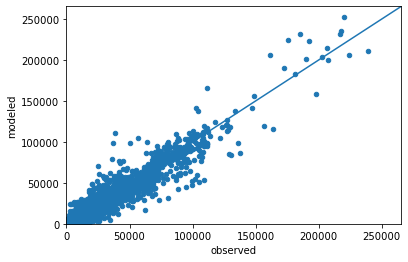

In [14]:
df = pd.read_csv(os.path.join(relative_path,'validation','daily_volume.csv'))
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)

In [15]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

r^2: 0.9545885085902143


---
By County

King r^2: 0.9732993765946544
Kitsap r^2: 0.9280928918817977
Pierce r^2: 0.9737998125315237
Snohomish r^2: 0.8370078294962757


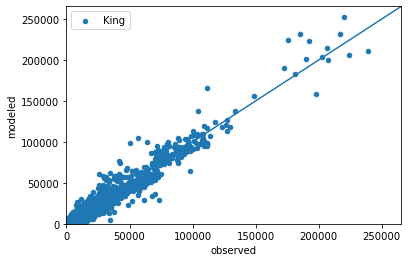

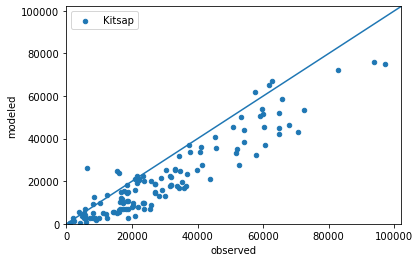

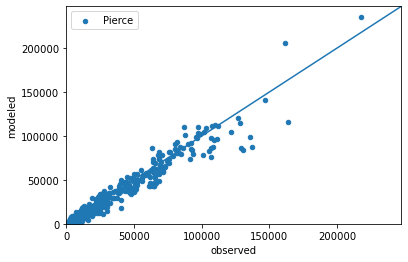

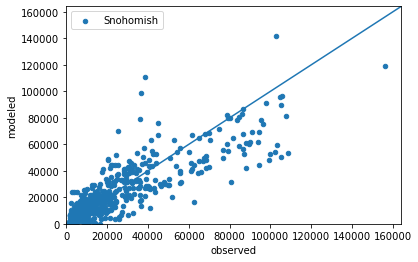

In [16]:
for county in np.unique(df[~df.county.isna()]['county']):
    _df = df[df['county'] == county]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=county)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    print(str(county) + ' r^2: ' + str(r_value))

#### City of SeaTac

Other r^2: 0.953305637080488
City of SeaTac r^2: 0.9669157149062554


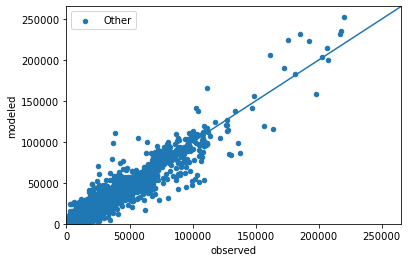

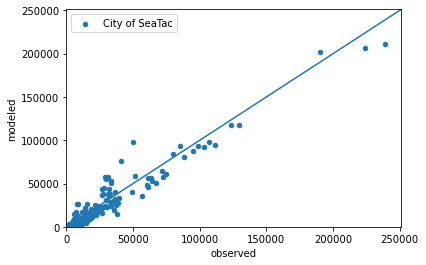

In [17]:
subarea_names = ['Other', 'City of SeaTac']
for county in np.unique(df[~df.county.isna()]['subarea_flag']):
    _df = df[df['subarea_flag'] == county]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=str(subarea_names[int(county)]))
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    print(str(subarea_names[int(county)]) + ' r^2: ' + str(r_value))

---
By Facility Type

r^2 Freeway: 0.921741487444675
r^2 Arterial: 0.8600921970344184


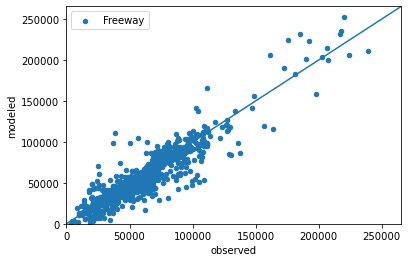

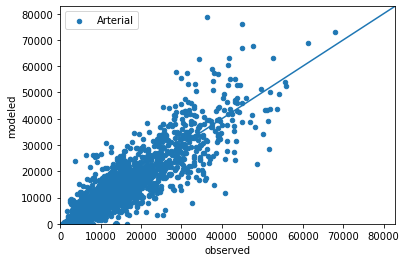

In [18]:
for factype in ['Freeway','Arterial']:
    _df = df[df['@facilitytype'] == factype]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    print('r^2 ' + str(factype) + ': ' + str(r_value))

By Facility Type - City of SeaTac

r^2 Freeway: 0.9755246370602667
r^2 Arterial: 0.8040637695950936


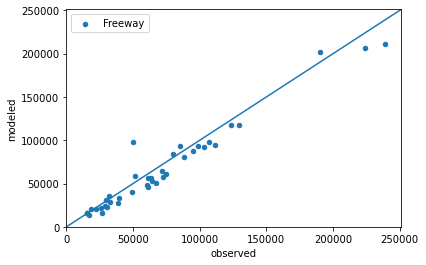

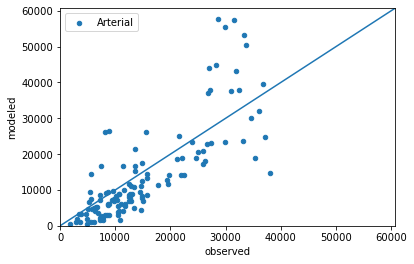

In [19]:
df1 = df[df['subarea_flag'] == 1]
for factype in ['Freeway','Arterial']:
    _df = df1[df1['@facilitytype'] == factype]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    print('r^2 ' + str(factype) + ': ' + str(r_value))

By Facility Type - Other Counties

r^2 Freeway: 0.9154678557127371
r^2 Arterial: 0.8658130189985822


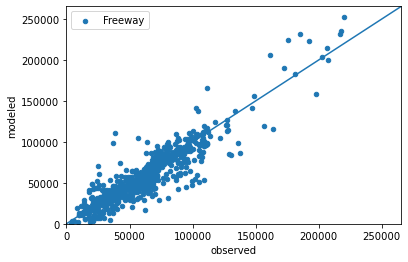

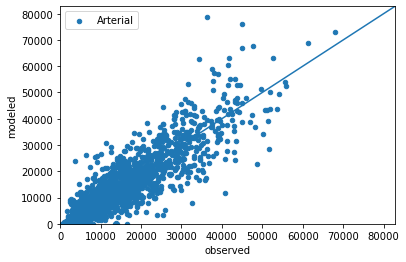

In [20]:
df2 = df[(df['subarea_flag'] != 1) & (~df.county.isna())]
if df2.shape[0] > 0:
    for factype in ['Freeway','Arterial']:
        _df = df2[df2['@facilitytype'] == factype]
        ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
        lim = _df[['observed','modeled']].max().max()*1.05
        ax.set_ylim(0,lim)
        ax.set_xlim(0,lim)
        x = np.linspace(*ax.get_xlim())
        ax.plot(x, x)
        slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
        print('r^2 ' + str(factype) + ': ' + str(r_value))

**Hourly Volumes**


r^2: 0.7391372479012605


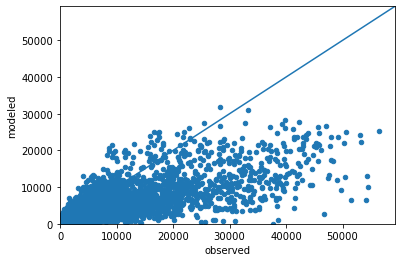

In [21]:
df = pd.read_csv(os.path.join(relative_path,'validation','hourly_volume.csv'))
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

**Hourly Volumes - City of SeaTac**

r^2: 0.8025714971013718


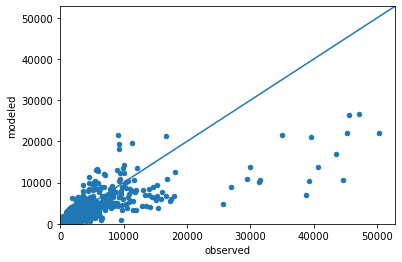

In [22]:
df1 = df[df['subarea_flag'] == 1]
ax = df1.plot(kind='scatter', x='observed', y='modeled')
lim = df1[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df1['observed'],df1['modeled'])
print('r^2: ' + str(r_value))

**Hourly Volumes - Other**

r^2: 0.673073976721919


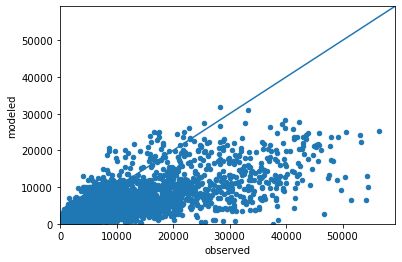

In [23]:
df2 = df[df['subarea_flag'] != 1]
ax = df2.plot(kind='scatter', x='observed', y='modeled')
lim = df2[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df2['observed'],df2['modeled'])
print('r^2: ' + str(r_value))

### Truck Counts

In [68]:
df = pd.read_csv(os.path.join(relative_path,'validation','daily_truck_volume.csv'))

##### Medium Trucks

In [71]:
_df = df.groupby('@facilitytype').sum()[['mtrk_vehicles','modeled_medt']].rename(columns={'modeled_medt':'modeled','mtrk_vehicles':'observed'})
_df = pd.concat([_df, pd.DataFrame([_df.sum()], index=['Total'])])
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
Freeway,"263,314","2,361,443","2,098,128",796.81%
Arterial,"218,362","799,002","580,640",265.91%
Collector,"19,072","59,918","40,846",214.17%
Ramp,"4,928","16,793","11,865",240.79%
Total,"505,675","3,249,807","2,744,131",542.67%


##### Heavy Trucks

In [73]:
_df = df.groupby('@facilitytype').sum()[['htrk_vehicles','modeled_hvyt']].rename(columns={'modeled_hvyt':'modeled','htrk_vehicles':'observed'})
_df = pd.concat([_df, pd.DataFrame([_df.sum()], index=['Total'])])
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
Freeway,"296,615","2,573,947","2,277,332",767.77%
Arterial,"86,268","192,534","106,266",123.18%
Collector,"2,400","10,720","8,319",346.64%
Ramp,"1,866","11,389","9,524",510.49%
Total,"387,148","2,803,763","2,416,614",624.21%


##### Total Trucks

In [77]:
_df = df.groupby('@facilitytype').sum()[['observed','modeled']]
_df = pd.concat([_df, pd.DataFrame([_df.sum()], index=['Total'])])
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
Freeway,"559,929","4,935,389","4,375,460",781.43%
Arterial,"304,629","991,536","686,907",225.49%
Collector,"21,472","70,637","49,166",228.98%
Ramp,"6,793","28,182","21,389",314.86%
Total,"892,824","6,053,569","5,160,746",578.03%


###### Scatter Plot

r^2: nan


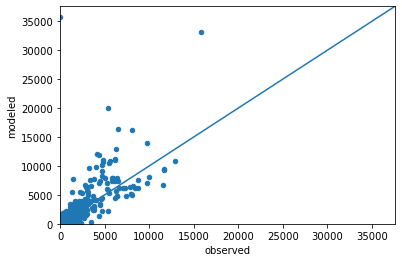

In [78]:
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

# Screenlines

In [79]:
df = pd.read_csv(os.path.join(relative_path,'validation','screenlines.csv'))
df = df[~df.name.isin(['KENT','SEATAC'])]
df = df.groupby(['name', 'county'], as_index=False).agg({'observed':'first', 'modeled':'sum'})
df['diff'] = df['modeled'] - df['observed']
df = df.append(df.sum(numeric_only=True), ignore_index=True)
df.at[df.index[-1], 'name'] = 'TOTAL'
#df.at['C', 'name'] = 10
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df.sort_values(['county','observed'], ascending=[True, False])

,name,county,observed,modeled,diff,percent_diff
1,AUBURN - SOUTH KING,King,"592,476","514,019","-78,457",-13.24%
24,SHIP CANAL,King,"481,563","498,650","17,087",3.55%
23,SEATTLE - SOUTH OF CBD,King,"473,322","459,110","-14,212",-3.00%
10,MILL CREEK,King,"391,447","414,142","22,695",5.80%
25,SOUTH BELLEVUE,King,"389,700","350,559","-39,141",-10.04%
7,KIRKLAND-REDMOND,King,"380,783","374,388","-6,395",-1.68%
22,SEATTLE - NORTH,King,"356,051","340,941","-15,110",-4.24%
2,BOTHELL,King,"291,573","285,937","-5,636",-1.93%
8,LYNNWOOD-BOTHELL,King,"260,099","271,007","10,908",4.19%
29,TUKWILA,King,"257,776","234,943","-22,833",-8.86%


r^2 : 0.9774702235739606


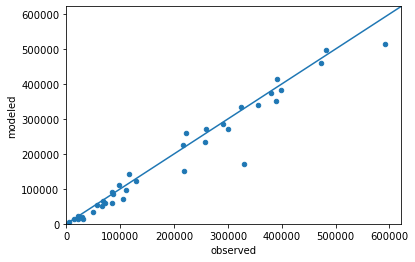

In [80]:
df = df.head(-1)
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2 : ' + str(r_value))

#### Screelines - City of Seatac

In [81]:
df = pd.read_csv(os.path.join(relative_path,'validation','screenlines.csv'))
df = df[~df.name.isin(['KENT','SEATAC'])]
df1 = df[(df['county'] == 'SeaTAC') & (df['name']!='KENT')].drop(columns='subarea_flag')
df1 = df1.groupby(['name', 'county'], as_index=False).agg({'observed':'first', 'modeled':'sum'})
df1['diff'] = df1['modeled'] - df1['observed']
df1 = df1.append(df1.sum(numeric_only=True), ignore_index=True)
df1.at[df1.index[-1], 'name'] = 'TOTAL'
#df1.at['C', 'name'] = 10
df1['percent_diff'] = df1['diff']/df1['observed']
df1[['percent_diff']] = df1[['percent_diff']].applymap(format_percent)
df1.sort_values(['county','observed'], ascending=[True, False])

,name,county,observed,modeled,diff,percent_diff
7,S of SEA Airport,SeaTAC,"398,837","383,569","-15,268",-3.83%
10,W of IH 5,SeaTAC,"329,527","169,793","-159,734",-48.47%
2,N of S 160th St,SeaTAC,"218,251","151,542","-66,709",-30.57%
3,N of S 200th St,SeaTAC,"216,377","226,325","9,948",4.60%
12,W of SR 99,SeaTAC,"109,861","98,068","-11,793",-10.73%
5,S of S 128th St,SeaTAC,"84,380","59,573","-24,807",-29.40%
4,N of SEA Airport,SeaTAC,"66,919","51,321","-15,598",-23.31%
1,Expy/SR 99/Cargo N of S 170th St,SeaTAC,"56,245","54,190","-2,055",-3.65%
6,S of S 144th St,SeaTAC,"48,532","32,607","-15,925",-32.81%
9,W of Des Moines Mem'l N of 176th,SeaTAC,"30,790","13,436","-17,354",-56.36%


r^2 : 0.9406246023023938


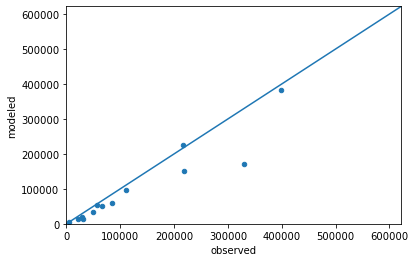

In [82]:
import warnings
warnings.filterwarnings('ignore')
df1 = df1.head(-1)
ax = df1.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df1['observed'],df1['modeled'])
print('r^2 : ' + str(r_value))

#### Screelines - Other

In [83]:
df2 = df[(df['county'] != 'SeaTAC') & ((df['name']!='KENT') | (df['name']!='SEATAC'))].drop(columns='subarea_flag').groupby(['name','county'],as_index=False).agg({'observed':'first','modeled':'sum'})
df2['diff'] = df2['modeled']-df2['observed']
df2 = df2.append(df2.sum(numeric_only=True), ignore_index=True)
df2.at[df2.index[-1], 'name'] = 'TOTAL'
#df2.at['C', 'name'] = 10
df2['percent_diff'] = df2['diff']/df2['observed']
df2[['percent_diff']] = df2[['percent_diff']].applymap(format_percent)
df2

,name,county,observed,modeled,diff,percent_diff
0,AGATE PASS BRIDGE,Kitsap,"21,000","22,316","1,316",6.27%
1,AUBURN - SOUTH KING,King,"592,476","514,019","-78,457",-13.24%
2,BOTHELL,King,"291,573","285,937","-5,636",-1.93%
3,CROSS SOUND,Kitsap,"14,302","14,610",308,2.16%
4,GIG HARBOR,Pierce,"84,875","90,313","5,438",6.41%
5,KIRKLAND-REDMOND,King,"380,783","374,388","-6,395",-1.68%
6,LYNNWOOD-BOTHELL,King,"260,099","271,007","10,908",4.19%
7,MAPLE VALLEY,King,"70,813","59,140","-11,673",-16.48%
8,MILL CREEK,King,"391,447","414,142","22,695",5.80%
9,NORTH KITSAP,Kitsap,"104,890","69,721","-35,169",-33.53%


r^2 : 0.9891243054544575


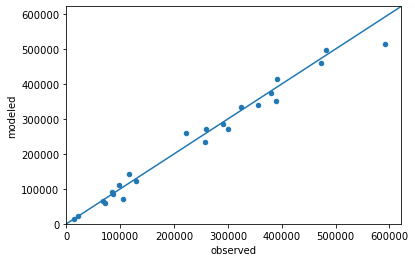

In [84]:
df2 = df2.head(-1)
if df2.shape[0] > 0:
    ax = df2.plot(kind='scatter', x='observed', y='modeled')
    lim = df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(df2['observed'],df2['modeled'])
    print('r^2 : ' + str(r_value))

# Transit Boarding
----
### By Agency

In [95]:
df

,agency,model_boardings,2023,2024,observed_5to20
0,Community Transit,"27,659","21,752","22,092","21,922"
1,Everett Transit,"3,585","4,201","5,862","5,032"
2,King County Metro,"296,962","254,568","263,641","259,105"
3,Kitsap Transit,"18,966","8,258","4,726","6,492"
4,Pierce Transit,"23,892","21,185","21,911","21,548"
5,Sound Transit,"137,366","115,114","133,536","124,325"
6,Washington Ferries,"6,207","7,883","8,614","8,248"


In [97]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_by_agency.csv')
df['observed_boardings'] = (df['2023']+df['2024'])/2
df['diff'] = df['model_boardings']-df['observed_boardings']
df[['observed_boardings','model_boardings','diff']] = df[['observed_boardings','model_boardings','diff']].astype('float')
sorted_values = df.sort_values('observed_boardings', ascending=False).agency.to_list() + ['TOTAL']
df = df.append(df.sum(numeric_only=True), ignore_index=True)
df.at[df.index[-1], 'agency'] = 'TOTAL'
df[['perc_diff']] = df['diff']/df['observed_boardings']
df[['perc_diff']] = df[['perc_diff']].applymap(format_percent)
df.set_index('agency').reindex(sorted_values)

,model_boardings,2023,2024,observed_boardings,diff,perc_diff
agency,,,,,,
King County Metro,"296,962","254,568","263,641","259,105","37,858",14.61%
Sound Transit,"137,366","115,114","133,536","124,325","13,041",10.49%
Community Transit,"27,659","21,752","22,092","21,922","5,737",26.17%
Pierce Transit,"23,892","21,185","21,911","21,548","2,344",10.88%
Washington Ferries,"6,207","7,883","8,614","8,248","-2,042",-24.75%
Kitsap Transit,"18,966","8,258","4,726","6,492","12,474",192.15%
Everett Transit,"3,585","4,201","5,862","5,032","-1,446",-28.75%
TOTAL,"514,637","432,961","460,382","446,672","67,965",15.22%


----
### By Transit Routes servicing City of SeaTac

In [98]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_by_lines_seatac.csv')
df[['route_code']] = df[['route_code']].astype(int).astype('str')
df['observed_boardings'] = (df['2023']+df['2024'])/2
df['diff'] = df['model_boardings']-df['observed_boardings']
df[['observed_boardings','model_boardings','diff']] = df[['observed_boardings','model_boardings','diff']].astype('float')
df = df[['agency','route_code', 'description', 'observed_boardings','model_boardings','diff']]
sorted_values = df.sort_values(['agency','observed_boardings'], ascending=False).route_code.to_list() + ['TOTAL']
df = df.append(df.sum(numeric_only=True), ignore_index=True)
df.at[df.index[-1], 'agency'] = 'TOTAL'
df.at[df.index[-1], 'route_code'] = 'TOTAL'
df.at[df.index[-1], 'description'] = 'TOTAL'
df[['perc_diff']] = df['diff']/df['observed_boardings']
df[['perc_diff']] = df[['perc_diff']].applymap(format_percent)
df.set_index('route_code').reindex(sorted_values)

,agency,description,observed_boardings,model_boardings,diff,perc_diff
route_code,,,,,,
6996,Sound Transit,Light Rail Ang Lk-NG,"84,992","84,857",-135,-0.16%
6574,Sound Transit,574 Lakewood-SeaTac,"1,817","1,922",105,5.77%
6578,Sound Transit,578 Seattle-Puyallup,"1,568","3,345","1,777",113.28%
6594,Sound Transit,594 Lakewood-Seattle,"1,410","2,304",893,63.32%
6560,Sound Transit,560 W Sea-Bellevue,"1,328","2,551","1,223",92.04%
6590,Sound Transit,590 Tacoma-Seattle,816,"1,302",485,59.43%
6577,Sound Transit,577 Fed Way-Seattle,776,"1,054",278,35.81%
6586,Sound Transit,586 Tacoma-U Dist,284,165,-119,-41.89%
6592,Sound Transit,592 DuPont-Seattle,266,216,-50,-18.79%


----
### By Transit Routes servicing Seattle Airport

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_by_lines_airport_seatac.csv')
df[['route_code']] = df[['route_code']].astype(int).astype('str')
df['observed_boardings'] = (df['2023']+df['2024'])/2
df['diff'] = df['model_boardings']-df['observed_boardings']
df[['observed_5to20','modeled_5to20','diff']] = df[['observed_5to20','modeled_5to20','diff']].astype('float')
df = df[['agency','route_code', 'description', 'observed_5to20','modeled_5to20','diff']]
sorted_values = df.sort_values(['agency','observed_5to20'], ascending=False).route_code.to_list() + ['TOTAL']
df = df.append(df.sum(numeric_only=True), ignore_index=True)
df.at[df.index[-1], 'agency'] = 'TOTAL'
df.at[df.index[-1], 'route_code'] = 'TOTAL'
df.at[df.index[-1], 'description'] = 'TOTAL'
df[['perc_diff']] = df['diff']/df['observed_5to20']
df[['perc_diff']] = df[['perc_diff']].applymap(format_percent)
df.set_index('route_code').reindex(sorted_values)

----
### Key Routes
#### Ferries

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_key_routes.csv', index_col='description')
df[['observed_5to20','modeled_5to20']] = df[['observed_5to20','modeled_5to20']].astype('float')
_df = df[df['route_code'].isin([5001,5002,5003,5004,5005,5006,5007,1973,1975])].reset_index()
_df.drop(['route_code','agency'], axis=1, inplace=True)
sorted_values = _df.sort_values('observed_5to20', ascending=False).description.to_list() + ['TOTAL']
_df = _df.append(_df.sum(numeric_only=True), ignore_index=True)
_df.at[_df.index[-1], 'description'] = 'TOTAL'
_df[['perc_diff']] = _df['diff']/_df['observed_5to20']
_df[['perc_diff']] = _df[['perc_diff']].applymap(format_percent)
_df

In [ ]:
if len(_df) > 0:
    ax = _df.plot(kind='scatter', x='observed_5to20', y='modeled_5to20')
    lim = _df[['observed_5to20','modeled_5to20']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed_5to20'],_df['modeled_5to20'])
    print('r^2 ' + str('') + ': ' + str(r_value))

#### Bikes on Ferries

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'bike_ferry_boardings.csv')
df['route_code'] = df['route_code'].astype('int')
df[['route_code','description', '@bvol']].sort_values('@bvol', ascending=False)

#### Rail

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_key_routes.csv', index_col='description')
df[['observed_5to20','modeled_5to20']] = df[['observed_5to20','modeled_5to20']].astype('float')
_df = df[df['route_code'].isin([6996,6999,6998])].reset_index()
_df['description'] = _df['route_code'].map({6998: 'Sounder South', 6999: 'Sounder North',6996: 'Link Red Line'})
_df.drop(['route_code','agency'], axis=1, inplace=True)
_df[['perc_diff']] = _df[['perc_diff']].applymap(format_percent)

_df

In [ ]:
if len(_df) > 0: 
    ax = _df.plot(kind='scatter', x='observed_5to20', y='modeled_5to20')
    lim = _df[['observed_5to20','modeled_5to20']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed_5to20'],_df['modeled_5to20'])
    print('r^2 ' + str('') + ': ' + str(r_value))

#### RapidRide, Busiest Buses, Streetcar

In [ ]:
_df = df[df['route_code'].isin([1671,1672,1673,1674,1675,1676,6550,1007,1040,1997,1998])].reset_index()
_df['description'] = _df['route_code'].map({1671: 'A Line RapidRide', 1672: 'B Line RapidRide',
                                            1673: 'C Line RapidRide', 1674: 'D Line RapidRide',
                                            1675: 'E Line RapidRide', 1676: 'F Line RapidRide',
                                            6550: 'Sound Transit 550', 1040: 'KC Metro 40', 1007: 'KC Metro 7',
                                            1997: 'SLU Streetcar', 1998: 'First Hill Streetcar'})
_df.drop(['route_code','agency'], axis=1, inplace=True)
_df[['perc_diff']] = _df[['perc_diff']].applymap(format_percent)
_df.sort_values('modeled_5to20', ascending=False)

In [ ]:
if len(_df) > 0: 
    ax = _df.plot(kind='scatter', x='observed_5to20', y='modeled_5to20')
    lim = _df[['observed_5to20','modeled_5to20']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed_5to20'],_df['modeled_5to20'])
    print('r^2 ' + str('') + ': ' + str(r_value))

---
### Lines by Agency

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_by_line.csv', index_col='agency')
df = df[-df['agency_id'].isnull()]

for agency in np.unique(df.index):
    _df = df.loc[agency,:]
    if (type(_df) == pd.core.frame.DataFrame) & (len(df) > 0):
        ax = _df.plot(kind='scatter', x='observed_5to20', y='modeled_5to20', label=agency)
        lim = _df[['observed_5to20','modeled_5to20']].max().max()*1.05
        ax.set_ylim(0,lim)
        ax.set_xlim(0,lim)
        x = np.linspace(*ax.get_xlim())
        ax.plot(x, x)
        slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed_5to20'],_df['modeled_5to20'])
        print('r^2 ' + str(agency) + ': ' + str(r_value))

# Light Rail Station Boardings
----
Red Line

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'light_rail_boardings.csv', index_col='station_name')
df['diff'] = df['modeled_5to20']-df['observed_5to20']
df['percent_diff'] = df['diff']/df['observed_5to20']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df

Sound Transit Station Groupings

In [ ]:
df_combined = df.copy()

df_combined['station_group'] = df.index
df_combined.loc[['Westlake'],'station_group'] = 'Westlake/University St'
df_combined.loc[['University St'],'station_group'] = 'Westlake/University St'

df_combined.loc[['Pioneer Square'],'station_group'] = "Pioneer Square/Int'l District"
df_combined.loc[["Int'l District"],'station_group'] = "Pioneer Square/Int'l District"

df_combined.loc[['Stadium'],'station_group'] = 'Stadium/SODO'
df_combined.loc[['SODO'],'station_group'] = 'Stadium/SODO'

df_combined.loc[['Beacon Hill'],'station_group'] = 'Beacon Hill/Mount Baker'
df_combined.loc[['Mount Baker'],'station_group'] = 'Beacon Hill/Mount Baker'

df_combined.loc[['Othello'],'station_group'] = 'Othello/Rainier Beach'
df_combined.loc[['Rainier Beach'],'station_group'] = 'Othello/Rainier Beach'

df_combined = df_combined.groupby('station_group').sum()[['observed_5to20','modeled_5to20']]
df_combined['diff'] = df_combined['modeled_5to20']-df_combined['observed_5to20']
df_combined['percent_diff'] = df_combined['diff']/df_combined['observed_5to20']
df_combined[['percent_diff']] = df_combined[['percent_diff']].applymap(format_percent)

df_combined.loc[['Husky Stadium','Capitol Hill','Westlake/University St',"Pioneer Square/Int'l District",
                 'Stadium/SODO','Beacon Hill/Mount Baker','Columbia City','Othello/Rainier Beach',
                "Tukwila Int'l Blvd",'SeaTac/Airport','Angle Lake']]

# Stop Transfers

### Light Rail

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'light_rail_transfers.csv', index_col='station_name')
pd.options.display.float_format = '{:0,.2f}'.format
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df

# Externals

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'external_volumes.csv', index_col='location')
pd.options.display.float_format = '{:0,.0f}'.format
df = df.drop('diff', axis=1)
df['diff'] = df['modeled']-df['observed']
df = df.fillna(0)
df.loc['Total',['observed','modeled','diff']] = df[['observed','modeled','diff']].sum()
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)

df[['external_station']] = df[['external_station']].applymap('{:0.0f}'.format)
df.replace('nan', '', regex=True)

# Corridor Speed

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
ax = df.plot(kind='scatter', y='model_speed', x='observed_speed')
maxlim = df[['observed_speed','model_speed']].max().max()*1.05
minlim = df[['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed_speed'],df['model_speed'])
print('r^2 ' + str('') + ': ' + str(r_value))

## City of SeaTac

In [ ]:
ax = df.loc[df.subarea_flag==1].plot(kind='scatter', y='model_speed', x='observed_speed')
maxlim = df.loc[df.subarea_flag==1][['observed_speed','model_speed']].max().max()*1.05
minlim = df.loc[df.subarea_flag==1][['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df[df.subarea_flag==1]['observed_speed'],df[df.subarea_flag==1]['model_speed'])
print('r^2 ' + str('') + ': ' + str(r_value))

## Other Counties

In [ ]:
_df = df.loc[df.subarea_flag!=1]
_df = _df.groupby(['Corridor_Number', 'tod'], as_index=False).agg({'auto_time':sum, 'length':sum,'observed_speed':np.mean}).\
assign(model_speed=lambda xdf: xdf.length*60/xdf.auto_time)
ax = _df.plot(kind='scatter', y='model_speed', x='observed_speed')
maxlim = _df[['observed_speed','model_speed']].max().max()*1.05
minlim = _df[['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed_speed'],_df['model_speed'])
print('r^2 ' + str('') + ': ' + str(r_value))

### AM Peak, Primary Corridors

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
ax = df[df['tod'] == '7to8'].plot(kind='scatter', x='observed_speed', y='model_speed')
maxlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].max().max()*1.05
minlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df[df['tod'] == '7to8']['observed_speed'],df[df['tod'] == '7to8']['model_speed'])
print('r^2 ' + str('') + ': ' + str(r_value))

In [ ]:
# Show daily AM and PM peaks by corridor
df[df['tod'] == '7to8'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

## City of SeaTac

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
df = df.loc[df.subarea_flag==1]
ax = df[df['tod'] == '7to8'].plot(kind='scatter', x='observed_speed', y='model_speed')
maxlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].max().max()*1.05
minlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df[df['tod'] == '7to8']['observed_speed'],df[df['tod'] == '7to8']['model_speed'])
print('r^2 ' + str('') + ': ' + str(r_value))

In [ ]:
# Show daily AM and PM peaks by corridor
df[df['tod'] == '7to8'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

## Other Counties

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
df = df.loc[df.subarea_flag!=1]
df = df.groupby(['Corridor_Number', 'Corridor_Description', 'tod'], as_index=False).agg({'auto_time':sum, 'length':sum,'observed_speed':np.mean}).\
assign(model_speed=lambda df: df.length*60/df.auto_time)
ax = df[df['tod'] == '7to8'].plot(kind='scatter', x='observed_speed', y='model_speed')
maxlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].max().max()*1.05
minlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df[df['tod'] == '7to8']['observed_speed'],df[df['tod'] == '7to8']['model_speed'])
print('r^2 ' + str('') + ': ' + str(r_value))

In [ ]:
# Show daily AM and PM peaks by corridor
df[df['tod'] == '7to8'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

### PM Peak, Primary Corridors

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
ax = df[df['tod'] == '16to17'].plot(kind='scatter', x='observed_speed', y='model_speed')
maxlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].max().max()*1.05
minlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df[df['tod'] == '16to17']['observed_speed'],df[df['tod'] == '16to17']['model_speed'])
print('r^2 ' + str('') + ': ' + str(r_value))

In [ ]:
df[df['tod'] == '16to17'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

## City of SeaTac

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
df = df.loc[df.subarea_flag==1]
ax = df[df['tod'] == '16to17'].plot(kind='scatter', x='observed_speed', y='model_speed')
maxlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].max().max()*1.05
minlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df[df['tod'] == '16to17']['observed_speed'],df[df['tod'] == '16to17']['model_speed'])
print('r^2 ' + str('') + ': ' + str(r_value))

In [ ]:
# Show daily AM and PM peaks by corridor
df[df['tod'] == '16to17'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

## Other

In [ ]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
df = df.loc[df.subarea_flag!=1]
df = df.groupby(['Corridor_Number', 'Corridor_Description', 'tod'], as_index=False).agg({'auto_time':sum, 'length':sum,'observed_speed':np.mean}).\
assign(model_speed=lambda df: df.length*60/df.auto_time)
ax = df[df['tod'] == '16to17'].plot(kind='scatter', x='observed_speed', y='model_speed')
maxlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].max().max()*1.05
minlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df[df['tod'] == '16to17']['observed_speed'],df[df['tod'] == '16to17']['model_speed'])
print('r^2 ' + str('') + ': ' + str(r_value))

In [ ]:
# Show daily AM and PM peaks by corridor
df[df['tod'] == '16to17'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)